# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadsammad42/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

Can historical search visibility and engagement signals be used to identify and rank content pages that are likely to become future content opportunities?

### Decision Supported

This analysis supports the decision of **which content pages should be prioritized for review or potential refresh**. The goal is to provide a data-driven ranking that helps content teams focus their limited review effort on the pages with the highest predicted opportunity.

The model is intended as **decision-support**, not as proof of what causes search rankings or future performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Ans: This capstone uses the **FlyRank internship warehouse release**, primarily the `fact_content_daily_performance` table. The analysis covers monthly content-level data from **January 2026 through May 2026**.

Impressions, clicks, and traffic metrics are aggregated as monthly volumes, while average search position is calculated as a mean. **June 2026 is treated as a sealed month and excluded from feature and outcome construction.**

Client names, domains, URLs, private queries, credentials, and raw exports are excluded to keep the analysis public-safe.

In [1]:
# Setup — Connect DuckDB to the FlyRank warehouse

%pip -q install duckdb

import os
import getpass
import duckdb
import pandas as pd
import numpy as np

# Get Hugging Face token from Colab Secrets
HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

if not HF_TOKEN:
    HF_TOKEN = getpass.getpass(
        "Paste your Hugging Face READ token (hf_...): "
    )

# Create DuckDB connection
con = duckdb.connect()

# Authenticate DuckDB with Hugging Face
con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

# Warehouse location
REL = "hf://datasets/FlyRank/internship-warehouse"

print("DuckDB connection established successfully.")

DuckDB connection established successfully.


In [2]:

# Load the Dataset
BASE = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance"

months_needed = [
    "2026-01",
    "2026-02",
    "2026-03",
    "2026-04",
    "2026-05"
]

monthly_frames = []

for m in months_needed:

    path = f"{BASE}/month={m}/*.parquet"

    query = f"""
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(gsc_impressions) AS gsc_impressions,
            SUM(gsc_clicks) AS gsc_clicks,
            AVG(gsc_avg_position) AS gsc_avg_position,

            SUM(ga4_pageviews) AS ga4_pageviews,
            SUM(ga4_sessions) AS ga4_sessions,
            SUM(ga4_engaged_sessions) AS ga4_engaged_sessions

        FROM read_parquet('{path}')

        GROUP BY
            client_hash_id,
            content_hash_id
    """

    print(f"Processing {m}...")

    df = con.sql(query).df()
    df["month"] = m

    monthly_frames.append(df)

monthly_data = pd.concat(
    monthly_frames,
    ignore_index=True
)

print("\nData verification complete.")
print(f"Release: FlyRank internship warehouse")
print(f"Primary table: fact_content_daily_performance")
print(f"Date window: {monthly_data['month'].min()} to {monthly_data['month'].max()}")
print(f"Total monthly content-level rows: {len(monthly_data):,}")

print("\nRows by month:")
print(monthly_data.groupby("month").size())

print("\nColumns:")
print(list(monthly_data.columns))

Processing 2026-01...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Processing 2026-02...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Processing 2026-03...


...

Processing 2026-04...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Processing 2026-05...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Data verification complete.
Release: FlyRank internship warehouse
Primary table: fact_content_daily_performance
Date window: 2026-01 to 2026-05
Total monthly content-level rows: 1,666,292

Rows by month:
month
2026-01    261984
2026-02    321546
2026-03    331437
2026-04    362172
2026-05    389153
dtype: int64

Columns:
['client_hash_id', 'content_hash_id', 'gsc_impressions', 'gsc_clicks', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_engaged_sessions', 'month']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Ans: The analysis assumes that past search visibility, ranking, and traffic signals can provide useful decision-support signals for identifying future content opportunities. Six monthly features were used: `gsc_impressions`, `gsc_clicks`, `gsc_avg_position`, `ga4_pageviews`, `ga4_sessions`, and `ga4_engaged_sessions`.

The target was a binary `future_opportunity` label. A page was labeled as an opportunity when its following-month impressions reached the training-derived threshold and its following-month average position was at least 8.0. The model used a Random Forest classifier with class balancing.

The Week-4 rule-based ranking approach was used as the baseline, and both approaches were evaluated using Precision@50 on the same validation month.

Validation was time-aware rather than random: January–March 2026 feature months were used for training, while April 2026 was held out for validation. May 2026 supplied the following-month outcomes for April. June 2026 remained sealed and was not used in model development.

To reduce leakage, future outcome metrics were kept separate from the feature variables, thresholds were derived from training data, and the validation month was not used for model fitting. The results are therefore treated as observed performance on this specific time-based split rather than evidence that the model will always outperform the baseline.

In [3]:
# Prepare model data

TRAIN_MONTHS = ["2026-01", "2026-02", "2026-03"]

# Derive the opportunity threshold from training months only
train_rows = monthly_data[
    monthly_data["month"].isin(TRAIN_MONTHS)
]

impression_threshold = train_rows[
    "gsc_impressions"
].quantile(0.75)

position_threshold = 8.0

# Map each feature month to the following outcome month
next_month = {
    "2026-01": "2026-02",
    "2026-02": "2026-03",
    "2026-03": "2026-04",
    "2026-04": "2026-05"
}

feature_rows = monthly_data[
    monthly_data["month"].isin(
        ["2026-01", "2026-02", "2026-03", "2026-04"]
    )
].copy()

feature_rows["outcome_month"] = (
    feature_rows["month"].map(next_month)
)

# Prepare following-month outcomes
future = monthly_data[
    monthly_data["month"].isin(
        ["2026-02", "2026-03", "2026-04", "2026-05"]
    )
].copy()

future = future.rename(
    columns={
        "month": "outcome_month",
        "gsc_impressions": "future_impressions",
        "gsc_clicks": "future_clicks",
        "gsc_avg_position": "future_position",
        "ga4_pageviews": "future_pageviews",
        "ga4_sessions": "future_sessions",
        "ga4_engaged_sessions": "future_engaged_sessions"
    }
)

# Join feature month with following-month outcome
model_data = feature_rows.merge(
    future[
        [
            "client_hash_id",
            "content_hash_id",
            "outcome_month",
            "future_impressions",
            "future_clicks",
            "future_position",
            "future_pageviews",
            "future_sessions",
            "future_engaged_sessions"
        ]
    ],
    on=[
        "client_hash_id",
        "content_hash_id",
        "outcome_month"
    ],
    how="inner"
)

# Define future opportunity
model_data["future_opportunity"] = (
    (model_data["future_impressions"] >= impression_threshold)
    &
    (model_data["future_position"] >= position_threshold)
).astype(int)

print("Model data prepared successfully.")
print("Rows:", f"{len(model_data):,}")
print("Opportunity rate:",
      round(model_data["future_opportunity"].mean(), 4))

Model data prepared successfully.
Rows: 1,259,164
Opportunity rate: 0.1656


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Ans:
The Random Forest and Week-4 baseline were evaluated on the same April 2026 validation split using Precision@50. The Random Forest achieved a Precision@50 of **1.00**, compared with **0.02** for the Week-4 baseline, an observed improvement of **0.98**.

These results are specific to this time-aware validation split and should be interpreted as decision-support evidence rather than proof that the Random Forest will consistently outperform the baseline.

In [4]:
# Part 4 — Results vs Baseline

from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

FEATURES = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_engaged_sessions"
]

TARGET = "future_opportunity"

# Time-aware split
train_data = model_data[
    model_data["month"].isin(
        ["2026-01", "2026-02", "2026-03"]
    )
].dropna(subset=FEATURES + [TARGET])

validation_data = model_data[
    model_data["month"] == "2026-04"
].dropna(subset=FEATURES + [TARGET])

X_train = train_data[FEATURES]
y_train = train_data[TARGET]

X_valid = validation_data[FEATURES]
y_valid = validation_data[TARGET]

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

# Model ranking scores
model_scores = rf.predict_proba(X_valid)[:, 1]

# Week-4 baseline ranking score
baseline_scores = (
    X_valid["gsc_impressions"].values /
    (X_valid["gsc_avg_position"].values + 1)
)

# Precision@50
def precision_at_k(y_true, scores, k=50):
    k = min(k, len(y_true))
    top_k = np.argsort(scores)[::-1][:k]
    return np.mean(np.asarray(y_true)[top_k])

model_p50 = precision_at_k(y_valid, model_scores, 50)
baseline_p50 = precision_at_k(y_valid, baseline_scores, 50)

# Honest comparison table
results = pd.DataFrame({
    "Method": [
        "Week-4 Baseline",
        "Random Forest"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ],
    "Validation rows": [
        len(y_valid),
        len(y_valid)
    ],
    "Positive rate": [
        y_valid.mean(),
        y_valid.mean()
    ]
})

results["Precision@50"] = results["Precision@50"].round(4)
results["Positive rate"] = results["Positive rate"].round(4)

display(results)

print(
    "\nObserved Precision@50 difference:",
    round(model_p50 - baseline_p50, 4)
)

,Method,Precision@50,Validation rows,Positive rate
0,Week-4 Baseline,0.02,142235,0.4081
1,Random Forest,1.00,142235,0.4081



Observed Precision@50 difference: 0.98


## 5. Limitations

*What this work cannot claim.*

Ans:
This analysis cannot establish that the Random Forest causes future content opportunities or improves Google rankings. The results are based on a specific FlyRank dataset, feature window, label definition, and April 2026 time-based validation split, so they may not generalize to other periods or datasets.

The `future_opportunity` label is a proxy based on future impressions and average position, not a direct measure of actual content-refresh success. Feature importance shows how the fitted model used the available signals, but does not establish causation.

Therefore, the model should be treated as a **decision-support and prioritization tool**, not as proof of Google's ranking behavior or guaranteed content performance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Ans: The model can be used as a prioritization tool by ranking validation-month content according to predicted future opportunity. Higher-probability items receive higher priority for review.

The recommended action playbook is:

1. **High priority:** Review the highest-ranked pages first for potential content refresh opportunities.
2. **Medium priority:** Review pages with moderate predicted opportunity and supporting search visibility.
3. **Monitor:** Track lower-ranked pages over time rather than prioritizing them immediately.

These recommendations are intended for decision support. A high model score indicates prioritization based on observed signals, not a guarantee that refreshing the page will improve search performance.

In [5]:
# Part 6 — Generate ranked recommendations

recommendations = validation_data[
    [
        "client_hash_id",
        "content_hash_id",
        "month",
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position"
    ]
].copy()

# Add model opportunity probability
recommendations["opportunity_score"] = model_scores

# Assign priority based on model score
recommendations["priority"] = pd.cut(
    recommendations["opportunity_score"],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["Monitor", "Medium", "High"]
)

# Rank highest-priority opportunities first
recommendations = recommendations.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = (
    recommendations.index + 1
)

# Show top 20 recommendations
ranked_recommendations = recommendations[
    [
        "rank",
        "content_hash_id",
        "opportunity_score",
        "priority",
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position"
    ]
].head(20)

display(ranked_recommendations)

,rank,content_hash_id,opportunity_score,priority,gsc_impressions,gsc_clicks,gsc_avg_position
0,1,content_6b5c4c849789343f,0.978159,High,13652.0,16.0,23.851264
1,2,content_3e03f1cb42dc93fb,0.978156,High,13612.0,17.0,27.503767
2,3,content_0f7a4c1d26aa1acb,0.978067,High,13371.0,16.0,25.843619
3,4,content_f98826400f5d3ad0,0.977958,High,10905.0,7.0,39.486284
4,5,content_8f8e591ee7fa75ff,0.977906,High,12926.0,18.0,27.907419
5,6,content_3beef766ea300c6e,0.977802,High,12679.0,16.0,34.624378
6,7,content_afdcdc6879ff4524,0.977790,High,12953.0,19.0,19.838109
7,8,content_55ce797653e8e95a,0.977790,High,14186.0,21.0,22.709901
8,9,content_a8cc67fa7838ad00,0.977790,High,13005.0,20.0,30.670117
9,10,content_fe313ca2e623b461,0.977739,High,15642.0,20.0,15.372361


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Ans: The capstone artifacts include a Precision@50 comparison between the Random Forest and the Week-4 baseline, a feature-importance chart showing which signals the fitted model relied on most, an opportunity-distribution chart, and a ranked view of the top content opportunities. These artifacts are generated directly from the final evaluation results and will be reused in the deployed research paper.

In [6]:
# Part 7.0 setup: Recreate the test split and model predictions

FEATURES = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_engaged_sessions"
]

TARGET = "future_opportunity"

data = model_data[
    FEATURES + [TARGET, "month"]
].dropna(
    subset=FEATURES + [TARGET]
)

# Same time-based split used in the model notebook
train_data = data[
    data["month"].isin(["2026-01", "2026-02", "2026-03"])
].copy()

test_data = data[
    data["month"] == "2026-04"
].copy()

X_train = train_data[FEATURES]
y_train = train_data[TARGET]

X_test = test_data[FEATURES]
y_test = test_data[TARGET]

# Recreate the Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

# Model probabilities
y_prob = rf.predict_proba(X_test)[:, 1]

print("Part 7 setup complete.")
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Part 7 setup complete.
Training rows: 256634
Test rows: 142235


In [7]:
# Part 7.1: Prepare paper-ready model vs baseline results

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def precision_at_k(y_true, scores, k=50):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = min(k, len(y_true))
    top_k = np.argsort(scores)[::-1][:k]

    return y_true[top_k].mean()


# Random Forest score
model_p50 = precision_at_k(
    y_test,
    y_prob,
    k=50
)

# Week-4 baseline score
baseline_score = (
    test_data["gsc_impressions"].values /
    (test_data["gsc_avg_position"].values + 1)
)

baseline_p50 = precision_at_k(
    y_test,
    baseline_score,
    k=50
)

comparison = pd.DataFrame({
    "Method": [
        "Week-4 Baseline",
        "Random Forest"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ]
})

comparison["Precision@50"] = comparison["Precision@50"].round(4)

display(comparison)

print(
    "Precision@50 improvement:",
    round(model_p50 - baseline_p50, 4)
)

,Method,Precision@50
0,Week-4 Baseline,0.02
1,Random Forest,1.00


Precision@50 improvement: 0.98


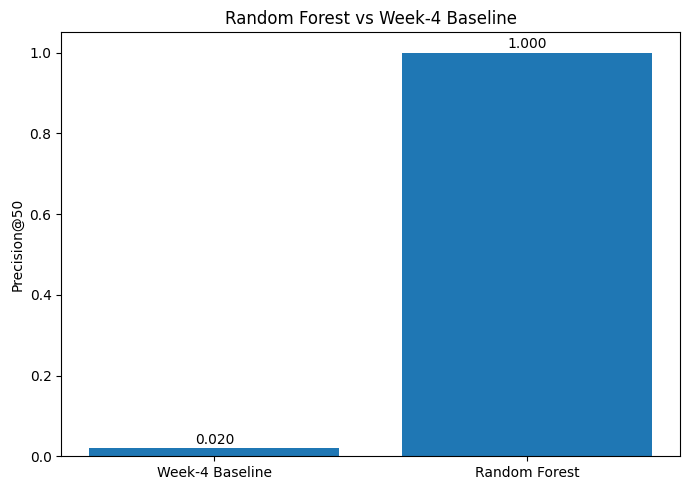

In [8]:
# Part 7.2: Model vs baseline

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Method"],
    comparison["Precision@50"]
)

plt.ylabel("Precision@50")
plt.title("Random Forest vs Week-4 Baseline")

for i, value in enumerate(comparison["Precision@50"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

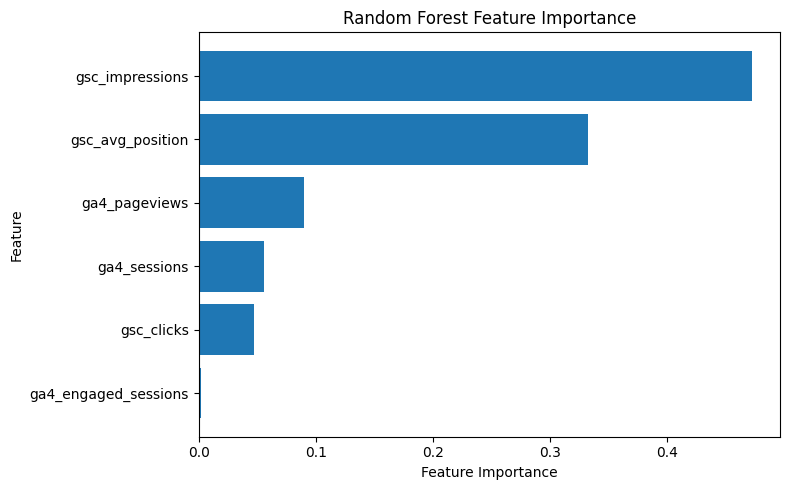

In [9]:
# Part 7.3: Feature importance

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

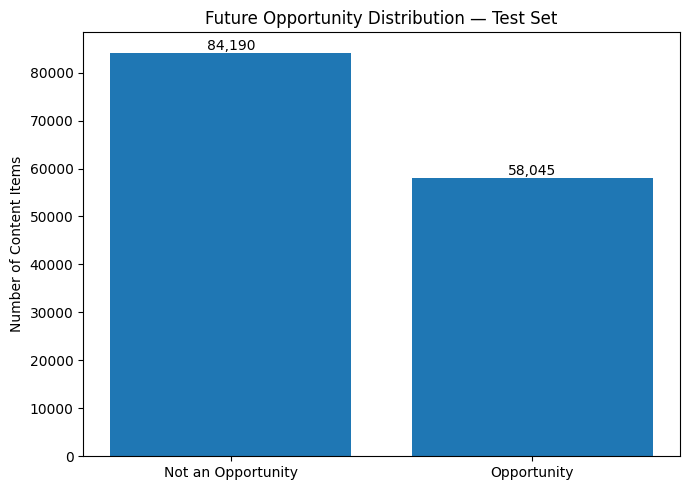

In [10]:
# Part 7.4: Future opportunity distribution

counts = y_test.value_counts().sort_index()

labels = [
    "Not an Opportunity",
    "Opportunity"
]

values = [
    counts.get(0, 0),
    counts.get(1, 0)
]

plt.figure(figsize=(7, 5))

plt.bar(labels, values)

plt.ylabel("Number of Content Items")
plt.title("Future Opportunity Distribution — Test Set")

for i, value in enumerate(values):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

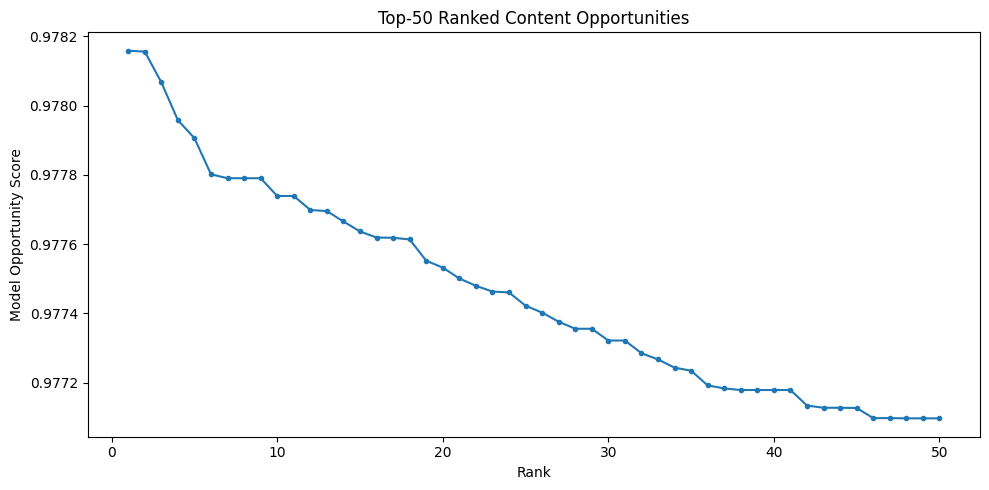

In [11]:
# Part 7.5: Top-50 ranked opportunities

ranking = test_data[
    [
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position",
        "ga4_pageviews"
    ]
].copy()

ranking["model_score"] = y_prob
ranking["actual_opportunity"] = y_test.values

top_50 = ranking.sort_values(
    "model_score",
    ascending=False
).head(50)

top_50["rank"] = range(1, len(top_50) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    top_50["rank"],
    top_50["model_score"],
    marker="o",
    markersize=3
)

plt.xlabel("Rank")
plt.ylabel("Model Opportunity Score")
plt.title("Top-50 Ranked Content Opportunities")

plt.tight_layout()
plt.show()

In [12]:
# Part 7.6: Paper-ready tables

print("Model vs Baseline")
display(comparison)

print("\nFeature Importance")

paper_feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).copy()

paper_feature_importance["importance"] = (
    paper_feature_importance["importance"].round(4)
)

display(paper_feature_importance)

print("\nTop 10 Ranked Opportunities")

display(
    top_50[
        [
            "rank",
            "model_score",
            "gsc_impressions",
            "gsc_clicks",
            "gsc_avg_position",
            "ga4_pageviews",
            "actual_opportunity"
        ]
    ].head(10)
)

Model vs Baseline


,Method,Precision@50
0,Week-4 Baseline,0.02
1,Random Forest,1.00



Feature Importance


,feature,importance
0,gsc_impressions,0.4729
2,gsc_avg_position,0.3322
3,ga4_pageviews,0.0897
4,ga4_sessions,0.0562
1,gsc_clicks,0.0471
5,ga4_engaged_sessions,0.0019



Top 10 Ranked Opportunities


,rank,model_score,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,actual_opportunity
1031665,1,0.978159,13652.0,16.0,23.851264,58.0,1
1222518,2,0.978156,13612.0,17.0,27.503767,123.0,1
969080,3,0.978067,13371.0,16.0,25.843619,70.0,1
1224143,4,0.977958,10905.0,7.0,39.486284,110.0,1
1224455,5,0.977906,12926.0,18.0,27.907419,48.0,1
1225213,6,0.977802,12679.0,16.0,34.624378,71.0,1
1225162,7,0.977790,12953.0,19.0,19.838109,82.0,1
1043052,8,0.977790,14186.0,21.0,22.709901,100.0,1
1057848,9,0.977790,13005.0,20.0,30.670117,106.0,1
1042299,10,0.977739,15642.0,20.0,15.372361,118.0,1


## ML-12: Five-Minute Demo Outline

### 1. Problem

Content teams have more pages to review than they can manually prioritize. This project asks whether a machine-learning ranking approach can identify future content opportunities more effectively than a transparent rule-based baseline.

### 2. Data & Approach

The analysis uses the FlyRank internship warehouse, specifically the `fact_content_daily_performance` table. Six search and engagement signals were used to build a one-month-ahead opportunity-ranking model. A Random Forest Classifier was compared against the Week-4 rule-based baseline.

### 3. Validation

The evaluation uses a strictly time-based split. January–March 2026 feature data was used for training, while April 2026 feature data was held out for evaluation against future-opportunity outcomes constructed from May 2026 data. This design avoids randomly mixing earlier and later observations.

### 4. Results

On the held-out evaluation period, the Random Forest achieved a measured Precision@50 of 1.00 compared with 0.02 for the Week-4 baseline. The strongest model feature contributions were `gsc_impressions` and `gsc_avg_position`.

### 5. Recommendations & Limitations

The resulting ranking can be used as a decision-support queue for prioritizing content review. High-scoring items should be investigated first, but human review remains necessary. The results are directional and observational, and the model does not predict Google's ranking algorithm or guarantee improvements in ranking or traffic.


## ML-12: Social Media Summary

I built a time-aware machine-learning ranking system during my FlyRank ML Internship to prioritize content opportunities using search and engagement signals. A Random Forest achieved a measured Precision@50 of 1.00 versus 0.02 for the Week-4 rule-based baseline on the held-out evaluation period. The result is a decision-support ranking approach—not a claim about Google's algorithm or a guarantee of future traffic or ranking improvements.


## ML-12: Employer-Facing Summary

I developed a time-aware Random Forest ranking model using real FlyRank search and engagement data to prioritize content items for future editorial review. I designed a one-month-ahead prediction setup with a strictly time-based evaluation split and compared the model against a transparent rule-based baseline, achieving a measured Precision@50 of 1.00 versus 0.02 on the held-out evaluation period. The project demonstrates practical experience in large-scale data querying, feature engineering, leakage-aware validation, machine-learning modeling, ranking evaluation, and translating model outputs into actionable decision-support recommendations.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
